# Lab 3 — Semantic Search

Run this notebook top to bottom as you build out `embeddings.py` and `search.py` in this same folder. See `Lab3_Instructions.md` for what belongs in each step.

This notebook is just a shell: it imports your functions and gives you a place to call them, but the corpus, example queries, and visualization are yours to write.

In [ ]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

from embeddings import _get_embedding_api, _get_embedding_offline
from search import load_documents, build_embedding_matrix, search

## Step 1-2: Load your corpus and fetch embeddings

In [26]:
# TODO: load_documents("documents.json") and build_embedding_matrix(documents)
# Start in offline mode (the default) while you're building - switch to the real
# API once your pipeline works end to end.
documents=load_documents('documents.json')
embedding_matrix=build_embedding_matrix(documents)
print(f'Loaded {len(documents)} document across {len(set(d['topic'] for d in documents))} topics.')
print(f'Embedding matrix shape: {embedding_matrix.shape}')

Loaded 20 document across 5 topics.
Embedding matrix shape: (20, 64)


## Step 3: Run a few example search queries

In [27]:
# TODO: call search(query, embedding_matrix, documents, top_k=3) with at least two
# different queries and print the results
example_queries=[
    'What is the capital of France',
    'How do neural networks work?'
]

for q in example_queries:
    print(f"Query:'{q!r}")

    for r in search(q, embedding_matrix, documents, top_k=3):
        print(f"[{r['score']: .3f}] ({r['topic']}) {r['text'][:70]}...")
    print()

Query:''What is the capital of France'
[ 0.663] (geography) Paris is the capital and most populous city of France, located along t...
[ 0.435] (geography) The Sahara Desert is the largest hot desert on Earth, stretching acros...
[ 0.424] (science) Photosynthesis is the process by which plants convert sunlight, water,...

Query:''How do neural networks work?'
[ 0.439] (history) The Industrial Revolution, beginning in the late 18th century, transfo...
[ 0.351] (technology) Cloud computing allows users to access computing resources such as ser...
[ 0.275] (geography) The Sahara Desert is the largest hot desert on Earth, stretching acros...



## Step 4: Visualize the embedding space with PCA

In [28]:
# TODO: reuse your Lab 2 PCA-via-SVD function (extended to 2 components) to project
# the embedding matrix down to 2D, then scatter-plot it colored by topic
def pca_svd(X, n_components=2):
    X_centered=X - X.mean(axis=0)
    U, S, Vt=np.linalg.svd(X_centered, full_matrices=False)
    return X_centered @ Vt[:n_components].T

In [29]:
coords_2d=pca_svd(embedding_matrix, n_components=2)

topics=[d['topic'] for d in documents]
unique_topics=sorted(set(topics))
colors=plt.cm.tab10(np.linspace(0, 1, len(unique_topics)))

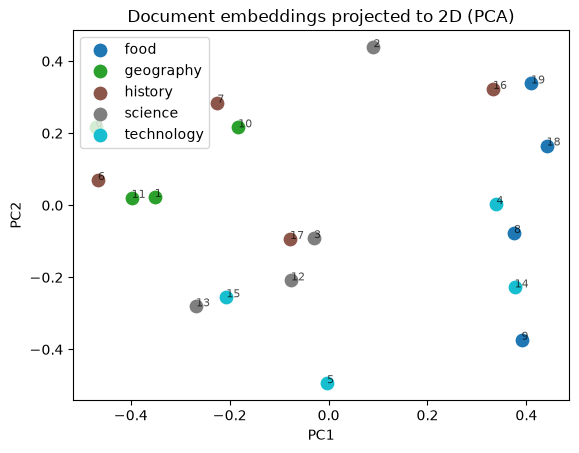

In [30]:
plt.Figure(figsize=(8, 6))
for topic, color in zip(unique_topics, colors):
    idxs=[i for i,t in enumerate(topics) if t==topic]
    plt.scatter(coords_2d[idxs, 0], coords_2d[idxs, 1], label=topic, color=color, s=80)

for i,doc in enumerate(documents):
    plt.annotate(str(doc['id']), (coords_2d[i, 0], coords_2d[i, 1]), fontsize=8, alpha=0.7)

plt.legend()
plt.title('Document embeddings projected to 2D (PCA)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()